#### *In This Notebook, I have done detailed Exploratory Data Analysis of my "Laptop_Prices" dataset.*
#### *You can go through each step of my analysis and if want to see the summary/conclusion you can see that at the end of notebook.*

---

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Importing Dataset

In [2]:
data = pd.read_csv("Laptop_Prices.csv")

warnings.filterwarnings('ignore')

# Basic Understanding

In [3]:
print(f"Total Rows: {data.shape[0]}")
print(f"Total Columns: {data.shape[1]}")

Total Rows: 937
Total Columns: 18


In [4]:
print(f"Duplicated Values: {data.duplicated().sum()}")

Duplicated Values: 2


In [5]:
print(f"Missing or Null Values:\n{data.isna().sum()}")

Missing or Null Values:
Brand           0
Laptop_Type     0
Launch_Year     0
CPU_Brand       0
CPU_Model       0
CPU_Cores       0
GPU_Type        0
GPU_VRAM        0
GPU_Model       0
Screen_Size     0
Resolution      0
Refresh_Rate    0
RAM             0
Storage         0
Storage_Type    0
Weight          0
OS              0
Price           0
dtype: int64


In [6]:
data['Brand'] = data['Brand'].astype('category')
data['Laptop_Type'] = data['Laptop_Type'].astype('category')
data['CPU_Brand'] = data['CPU_Brand'].astype('category')
data['GPU_Type'] = data['GPU_Type'].astype('category')
data['Storage_Type'] = data['Storage_Type'].astype('category')
data['OS'] = data['OS'].astype('category')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Brand         937 non-null    category
 1   Laptop_Type   937 non-null    category
 2   Launch_Year   937 non-null    int64   
 3   CPU_Brand     937 non-null    category
 4   CPU_Model     937 non-null    object  
 5   CPU_Cores     937 non-null    int64   
 6   GPU_Type      937 non-null    category
 7   GPU_VRAM      937 non-null    object  
 8   GPU_Model     937 non-null    object  
 9   Screen_Size   937 non-null    int64   
 10  Resolution    937 non-null    object  
 11  Refresh_Rate  937 non-null    int64   
 12  RAM           937 non-null    int64   
 13  Storage       937 non-null    int64   
 14  Storage_Type  937 non-null    category
 15  Weight        937 non-null    float64 
 16  OS            937 non-null    category
 17  Price         937 non-null    int64   
dtypes: categor

In [8]:
data.describe()

,Launch_Year,CPU_Cores,Screen_Size,Refresh_Rate,RAM,Storage,Weight,Price
count,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.00000,937.000000
mean,2024.338314,11.393810,14.914621,105.723586,20.448239,927.423693,1.80047,143920.617930
std,0.935845,4.925479,1.038351,55.607094,12.894449,895.196025,0.49034,109563.817294
min,2023.000000,2.000000,11.000000,60.000000,4.000000,64.000000,0.85000,22990.000000
25%,2024.000000,8.000000,14.000000,60.000000,16.000000,512.000000,1.44000,75100.000000
50%,2025.000000,10.000000,15.000000,60.000000,16.000000,512.000000,1.69000,107990.000000
75%,2025.000000,14.000000,16.000000,144.000000,24.000000,1024.000000,2.10000,173300.000000
max,2026.000000,24.000000,18.000000,360.000000,128.000000,8192.000000,4.30000,779900.000000


#### 1. In my dataset there are no missing or null values.
#### 2. There are 2 duplicated values in my dataset.
#### 3. In my dataset I have wide variety of laptops ranging from (₹22,990 - ₹7,79,900).
#### 4. Most laptops are 15' inches with 16GB Ram and 1TB Storage with weight of 1.8Kg.

 ---

# Exploratory Data Analysis

## 1. Target Variable [Price] Analysis.

In [9]:
print(f"Maximum Price:      ₹{data['Price'].max()}")
print(f"Minimum Price:      ₹{data['Price'].min()}")
print(f"Mean:               ₹{data['Price'].mean():.2f}")
print(f"Median:             ₹{data['Price'].median()}")
print(f"Variance:           {data['Price'].var():.2f}")
print(f"Standard Deviation: {data['Price'].std():.2f}")

Maximum Price:      ₹779900
Minimum Price:      ₹22990
Mean:               ₹143920.62
Median:             ₹107990.0
Variance:           12004230059.97
Standard Deviation: 109563.82


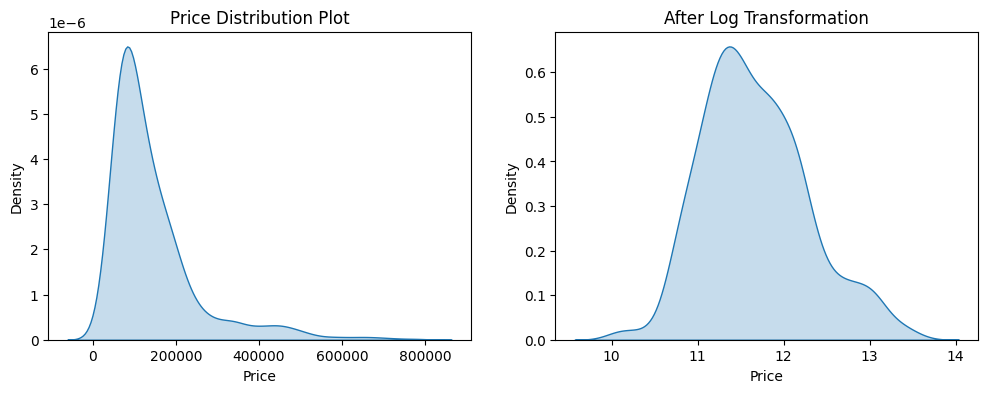

Skewness: 2.3056156660844094


In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.kdeplot(data, x=data['Price'], fill=True, ax=ax[0])
ax[0].set_title("Price Distribution Plot")

sns.kdeplot(data, x=np.log(data['Price']), fill=True, ax=ax[1])
ax[1].set_title("After Log Transformation")

plt.show()

print(f"Skewness: {data['Price'].skew()}")

#### Price Column is right skewed as we can see in kernel density plot, so we need to use "Log Transform".

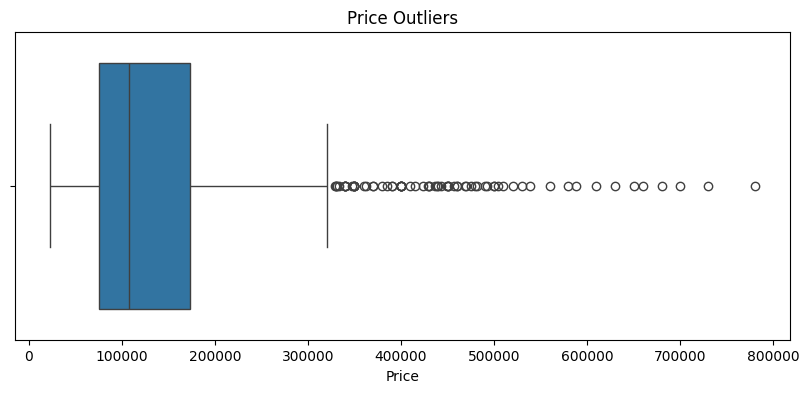

In [11]:
plt.figure(figsize=(10,4))

sns.boxplot(data, x=data['Price'])
plt.title('Price Outliers')

plt.show()

#### It has many outliers it will be fixed using "Robust Sclaing".

 ---

## 2. Categorical Columns Analysis.

In [12]:
category_cols = data.select_dtypes(include=['category']).columns.tolist()

print(f"All Categorical Columns: {category_cols}")

All Categorical Columns: ['Brand', 'Laptop_Type', 'CPU_Brand', 'GPU_Type', 'Storage_Type', 'OS']


### a) Brand

Total Brands: 8

Brand
Lenovo     282
Asus       136
HP         123
MSI        102
Apple       96
Acer        90
Dell        65
Samsung     43
Name: count, dtype: int64

Brand
Apple      269900.0
Samsung    140990.0
MSI        124990.0
Lenovo     118400.0
HP          89990.0
Dell        81299.0
Asus        77990.0
Acer        60858.5
Name: Price, dtype: float64


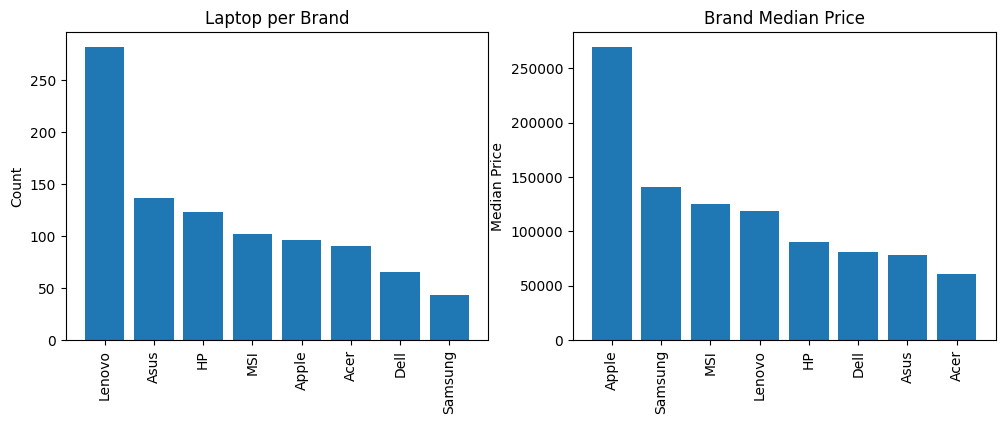

In [13]:
count_Brands = data['Brand'].value_counts()
brand_median_price = data.groupby('Brand')['Price'].median().sort_values(ascending=False)

print(f"Total Brands: {data['Brand'].nunique()}")
print(f"\n{count_Brands}")
print(f"\n{brand_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_Brands.index, count_Brands.values)
ax[0].set_title('Laptop per Brand')
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_ylabel('Count')

ax[1].bar(brand_median_price.index, brand_median_price.values)
ax[1].set_title('Brand Median Price')
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_ylabel('Median Price')

plt.show()

#### We have total 8 different brands, we will feature-engineer it with brand having laptops less than 70 -> others and then we can do "One-Hot-Encoding" on brand column.
#### Median Price per Brand varies with the brand being apple selling the expensive laptops and acer,asus having budget laptops, therefore Brand column is useful for predicting laptop prices.

 ---

### b) Laptop Type

Types of Laptop: 7

Laptop_Type
Gaming                276
Notebook              226
Business              164
Ultrabook             120
2-in-1 Convertible     73
Workstation            52
Creator                26
Name: count, dtype: int64

Laptop_Type
Workstation           399900.0
Creator               204900.0
Gaming                149990.0
2-in-1 Convertible    128200.0
Ultrabook             125450.0
Business              100500.0
Notebook               64990.0
Name: Price, dtype: float64


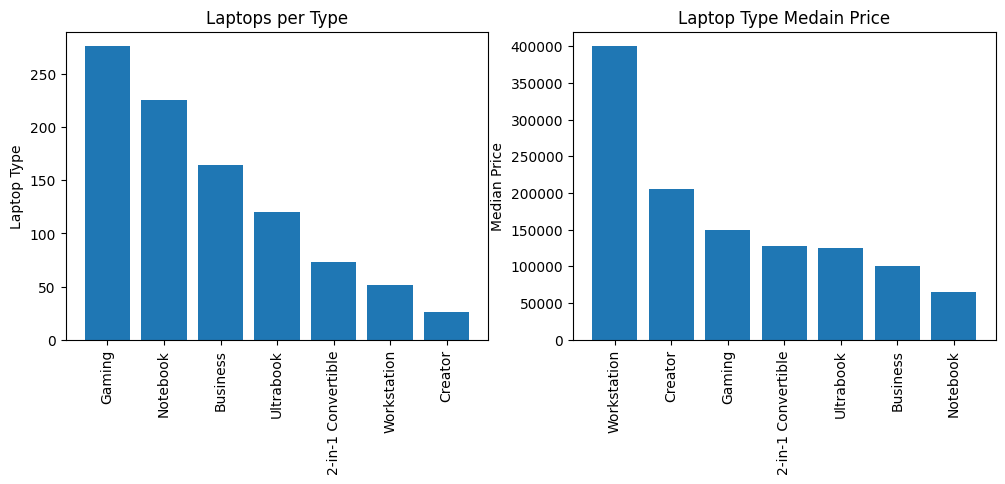

In [14]:
count_laptop_type = data['Laptop_Type'].value_counts()
laptop_type_median_price = data.groupby('Laptop_Type')['Price'].median().sort_values(ascending=False)

print(f"Types of Laptop: {data['Laptop_Type'].nunique()}")
print(f"\n{count_laptop_type}")
print(f"\n{laptop_type_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_laptop_type.index, count_laptop_type.values)
ax[0].set_title('Laptops per Type')
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_ylabel('Laptop Type')

ax[1].bar(laptop_type_median_price.index, laptop_type_median_price.values)
ax[1].set_title('Laptop Type Medain Price')
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_ylabel('Median Price')

plt.show()

#### We have around 7 different types of laptops, so we can do "One-Hot-Encoding" on Laptop Type Column too.
#### If we see the Medain price per laptop type, it is different for most of the different types of laptop, so this Laptop Type column is useful in predicting Laptop Prices

 ---

### c) CPU Brand

Total CPU Brands: 4

CPU_Brand
Intel       612
AMD         205
Apple        96
Qualcomm     24
Name: count, dtype: int64

CPU_Brand
Apple       269900.0
Intel       101250.0
AMD          96250.0
Qualcomm     93494.5
Name: Price, dtype: float64


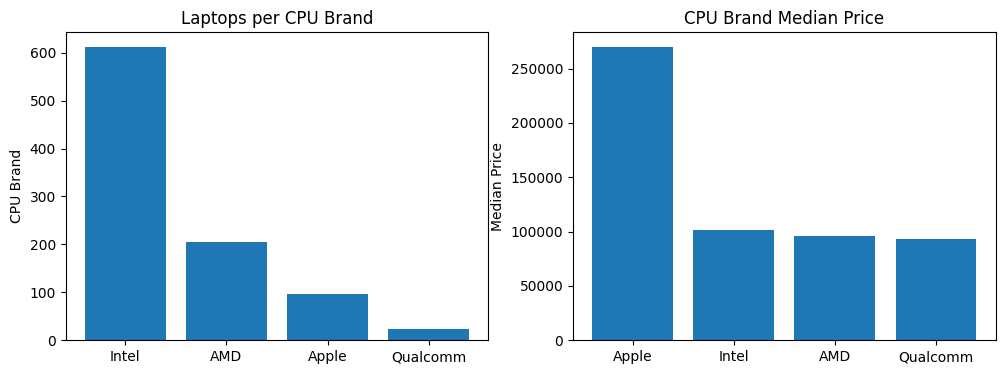

In [15]:
count_cpu_brand = data['CPU_Brand'].value_counts()
cpu_brand_median_price = data.groupby('CPU_Brand')['Price'].median().sort_values(ascending=False)

print(f"Total CPU Brands: {data['CPU_Brand'].nunique()}")
print(f"\n{count_cpu_brand}")
print(f"\n{cpu_brand_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_cpu_brand.index, count_cpu_brand.values)
ax[0].set_title('Laptops per CPU Brand')
ax[0].set_ylabel('CPU Brand')

ax[1].bar(cpu_brand_median_price.index, cpu_brand_median_price.values)
ax[1].set_title('CPU Brand Median Price')
ax[1].set_ylabel('Median Price')

plt.show()

#### We have 4 different cpu brands, so we can "One-Hot-Encode" them.
#### The median price per cpu brand is almost same for windows laptop but apple cpu have a higher price, so this CPU Brand column can also be useful for predicting Laptop Prices.

 ---

### d) GPU Type

Types of GPU: 2

GPU_Type
Integrated    630
Dedicated     307
Name: count, dtype: int64

GPU_Type
Dedicated     146100.0
Integrated     94990.0
Name: Price, dtype: float64


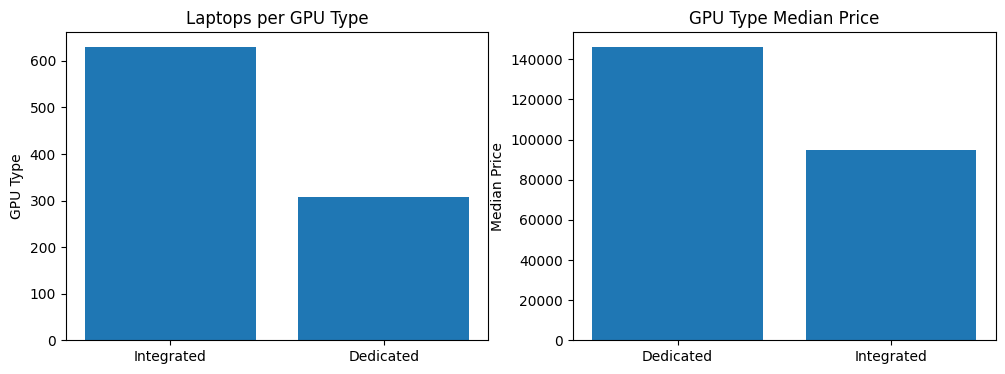

In [16]:
count_gpu_type = data['GPU_Type'].value_counts()
gpu_type_median_price = data.groupby('GPU_Type')['Price'].median().sort_values(ascending=False)

print(f"Types of GPU: {data['GPU_Type'].nunique()}")
print(f"\n{count_gpu_type}")
print(f"\n{gpu_type_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_gpu_type.index, count_gpu_type.values)
ax[0].set_title('Laptops per GPU Type')
ax[0].set_ylabel('GPU Type')

ax[1].bar(gpu_type_median_price.index, gpu_type_median_price.values)
ax[1].set_title('GPU Type Median Price')
ax[1].set_ylabel('Median Price')

plt.show()

#### We have 2 different types of gpu, so we can use "Label-Encoding" or "One-Hot-Encoding" on GPU Type column.
#### GPU Type Column is also useful in predicting Laptop Prices, as Dedicated GPU are expensive Comapred To Integrated GPU. 

 ---

### e) Storage Type

Types of Storages: 2

Storage_Type
SSD     930
eMMC      7
Name: count, dtype: int64

Storage_Type
SSD     107990.0
eMMC     23990.0
Name: Price, dtype: float64


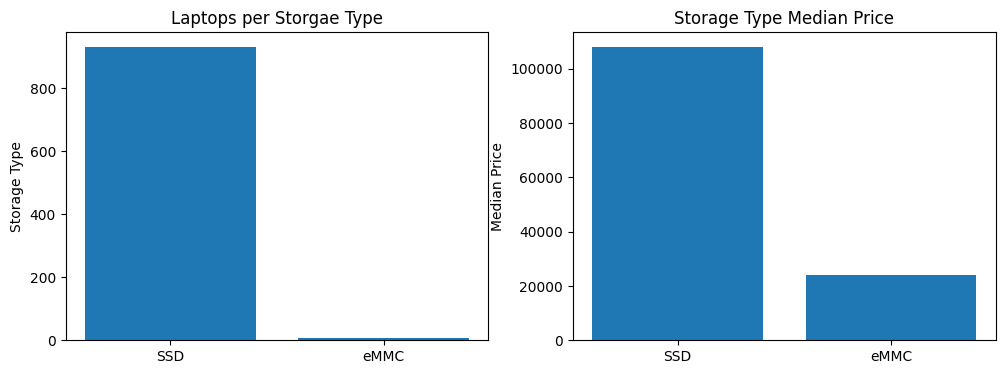

In [17]:
count_storage_type = data['Storage_Type'].value_counts()
storage_type_median_price = data.groupby('Storage_Type')['Price'].median().sort_values(ascending=False)

print(f"Types of Storages: {data['Storage_Type'].nunique()}")
print(f"\n{count_storage_type}")
print(f"\n{storage_type_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_storage_type.index, count_storage_type.values)
ax[0].set_title('Laptops per Storgae Type')
ax[0].set_ylabel('Storage Type')

ax[1].bar(storage_type_median_price.index, storage_type_median_price.values)
ax[1].set_title('Storage Type Median Price')
ax[1].set_ylabel('Median Price')

plt.show()

#### 99% of the laptops have storage type 'SSD', this column is not so useful so this can be droped.

 ---

### f) Operating System

OS: 3

OS
Windows     834
macOS        96
ChromeOS      7
Name: count, dtype: int64

OS
macOS       269900.0
Windows     100990.0
ChromeOS     23990.0
Name: Price, dtype: float64


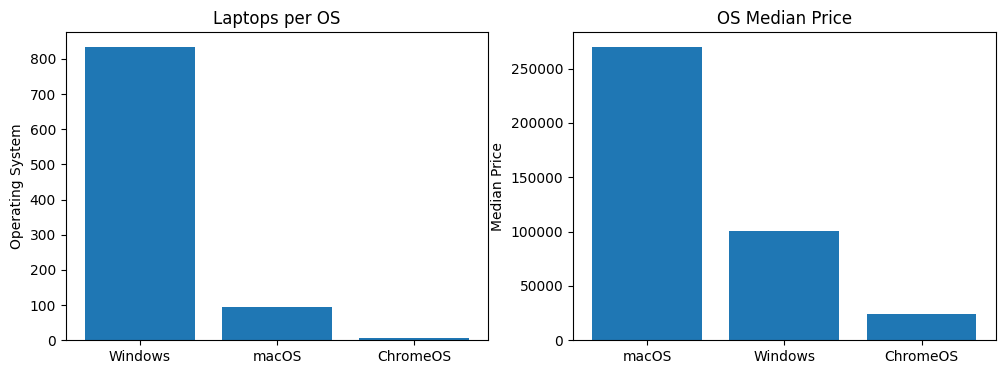

In [18]:
count_os = data['OS'].value_counts()
os_median_price = data.groupby('OS')['Price'].median().sort_values(ascending=False)

print(f"OS: {data['OS'].nunique()}")
print(f"\n{count_os}")
print(f"\n{os_median_price}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

ax[0].bar(count_os.index, count_os.values)
ax[0].set_title('Laptops per OS')
ax[0].set_ylabel('Operating System')

ax[1].bar(os_median_price.index, os_median_price.values)
ax[1].set_title('OS Median Price')
ax[1].set_ylabel('Median Price')

plt.show()

#### We have 3 different Operating System, we can make a new column from the existing OS column and in that we can feature engineer the chromeOS into other so if some other os like linux comes it gets under other category and kept windows and macOS as it is as they have the most market share and drop the old column and  "One-Hot-Encode" the new OS column.

#### This column is also useful in predicting laptop price, as we have a quiet large variation in median prices. 

 ---

## 2. Numerical Column Analysis.

In [19]:
numerical_cols = data.select_dtypes(include=['int', 'float']).columns.tolist()
print(f"All Numerical Columns: {numerical_cols}")

All Numerical Columns: ['Launch_Year', 'CPU_Cores', 'Screen_Size', 'Refresh_Rate', 'RAM', 'Storage', 'Weight', 'Price']


### a) Launch Year.

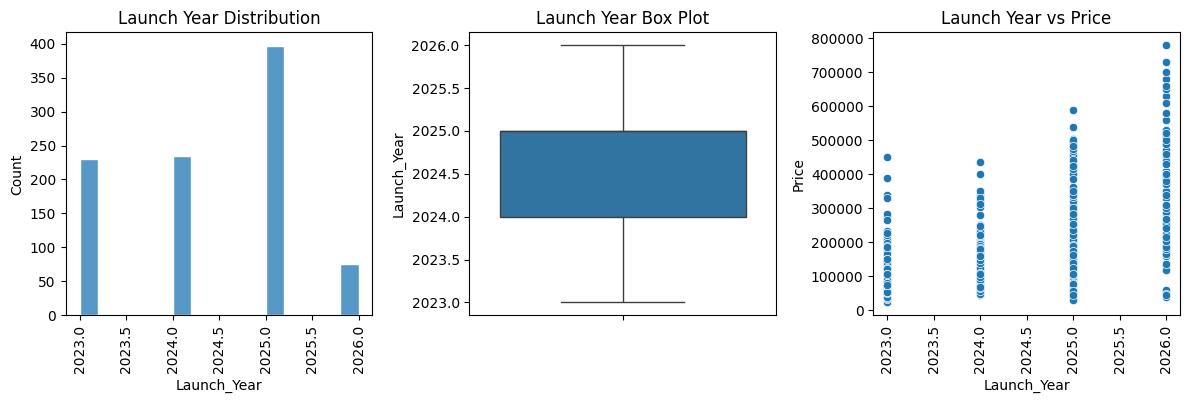

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Launch_Year'], edgecolor='white', ax=ax[0])
ax[0].set_title("Launch Year Distribution")
ax[0].tick_params(axis='x', rotation=90)

sns.boxplot(data, y=data['Launch_Year'], ax=ax[1])
ax[1].set_title('Launch Year Box Plot')

sns.scatterplot(data, x=data['Launch_Year'], y=data['Price'], ax=ax[2])
ax[2].set_title('Launch Year vs Price')
ax[2].tick_params(axis='x', rotation=90)

fig.tight_layout()
plt.show()

#### launch Year Column is useful for predicting Laptop prices, as price increases with the year.
#### We can feature engineer this column to Laptop_Age, as the laptop is old it is cheaper compare to newer ones and we can see in the price vs launch year plot too.

 ---

### b) CPU Cores.

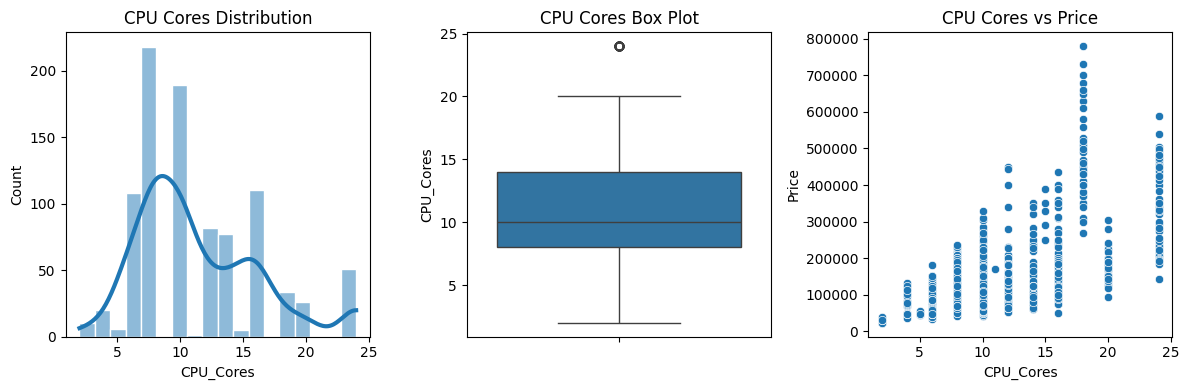

Skewness: 0.8690118129479835


In [21]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['CPU_Cores'], kde=True, line_kws={'linewidth':3}, edgecolor='white', ax=ax[0])
ax[0].set_title("CPU Cores Distribution")

sns.boxplot(data, y=data['CPU_Cores'], ax=ax[1])
ax[1].set_title('CPU Cores Box Plot')

sns.scatterplot(data, x=data['CPU_Cores'], y=data['Price'], ax=ax[2])
ax[2].set_title('CPU Cores vs Price')

fig.tight_layout()
plt.show()

print(f"Skewness: {data['CPU_Cores'].skew()}")

#### The Distribution is right-skewed but its < 1 and its discrete, so it will be as it is and there is only 1 outlier, we can handle it using Robust Scaling.
#### CPU Cores Column is useful for predictiong laptop prices, as price increses with the core counts.

 ---

### c) Screen Size.

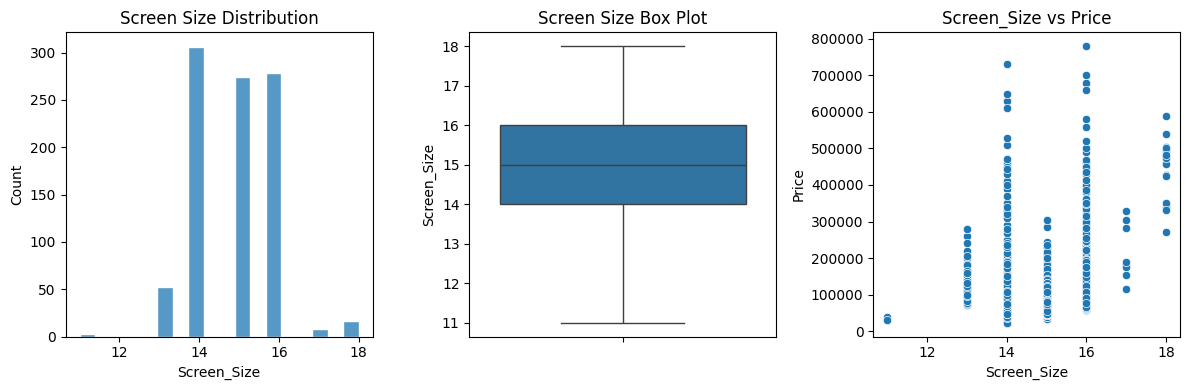

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Screen_Size'], edgecolor='white', ax=ax[0])
ax[0].set_title("Screen Size Distribution")

sns.boxplot(data, y=data['Screen_Size'], ax=ax[1])
ax[1].set_title('Screen Size Box Plot')

sns.scatterplot(data, x=data['Screen_Size'], y=data['Price'], ax=ax[2])
ax[2].set_title('Screen_Size vs Price')

fig.tight_layout()
plt.show()

#### With increase in screen size the Price does not increses, instead it has a mixed correlation, so the Screen Size Column is not so useful so it can be droped.
#### This column can be used in feature engineering with Resolution Column to make a new column PPI (Pixel Per Inch).

 ---

### d) Refresh Rate.

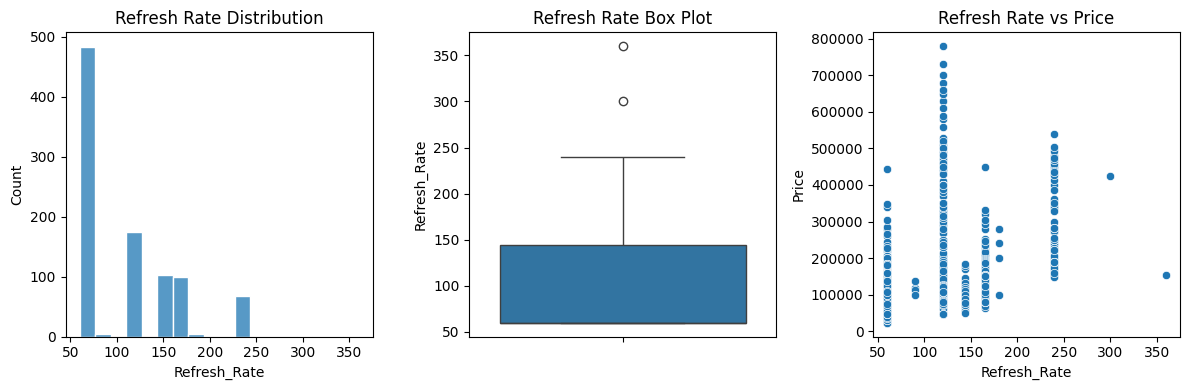

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Refresh_Rate'], edgecolor='white', ax=ax[0])
ax[0].set_title('Refresh Rate Distribution')

sns.boxplot(data, y=data['Refresh_Rate'], ax=ax[1])
ax[1].set_title('Refresh Rate Box Plot')

sns.scatterplot(data, x=data['Refresh_Rate'], y=data['Price'], ax=ax[2])
ax[2].set_title('Refresh Rate vs Price')

plt.tight_layout()
plt.show()

#### The Refresh Rate Column has a mixed correlation with price, so this column is not so useful so we can drop it.
#### (not droping this column after analysing correlation matrix)

 ---

### e) RAM.

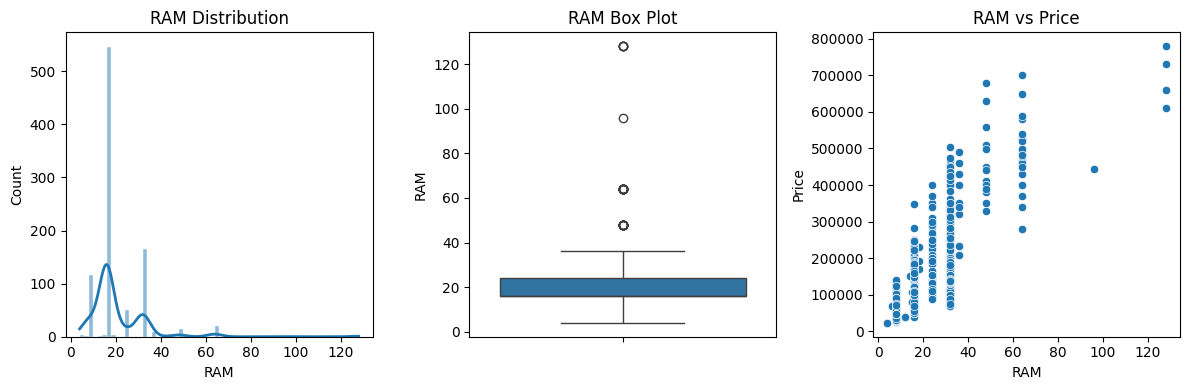

Skewness: 3.6701186591455293


In [24]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['RAM'], kde=True, line_kws={'linewidth':2}, edgecolor='white', ax=ax[0])
ax[0].set_title('RAM Distribution')

sns.boxplot(data, y=data['RAM'], ax=ax[1])
ax[1].set_title('RAM Box Plot')

sns.scatterplot(data, x=data['RAM'], y=data['Price'], ax=ax[2])
ax[2].set_title('RAM vs Price')

plt.tight_layout()
plt.show()

print(f"Skewness: {data['RAM'].skew()}")

#### The RAM has strong correlation with the Price, as it shows a linear growth, so this column is useful in predicting Laptop Prices.
#### The Distribution is Discrete with 16GB Ram the most this can creates a bias, so we can use log transform while training the data and it has many outliers, we can handle it using Robust Scaling .

---

### f) Storage.

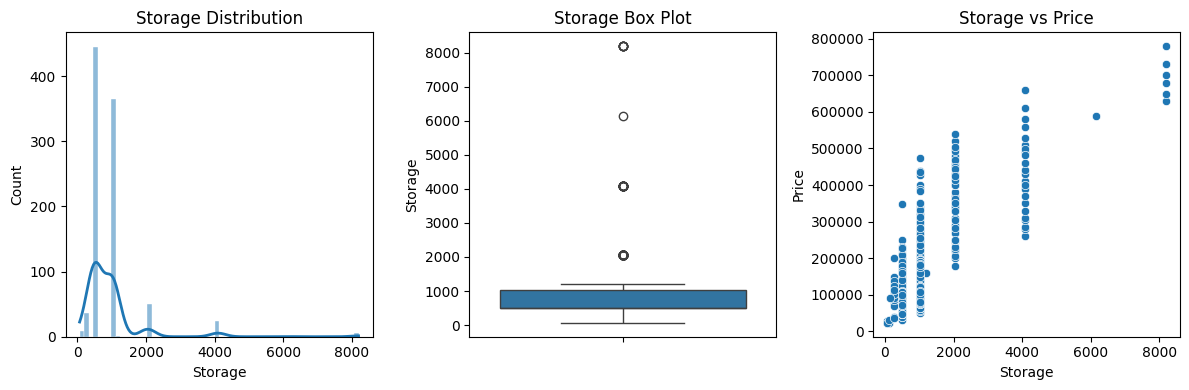

Skewness: 4.81827363749194


In [25]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Storage'], kde=True, line_kws={'linewidth':2}, edgecolor='white', ax=ax[0])
ax[0].set_title('Storage Distribution')

sns.boxplot(data, y=data['Storage'], ax=ax[1])
ax[1].set_title('Storage Box Plot')

sns.scatterplot(data, x=data['Storage'], y=data['Price'], ax=ax[2])
ax[2].set_title('Storage vs Price')

plt.tight_layout()
plt.show()

print(f"Skewness: {data['Storage'].skew()}")

#### The Storage has strong correlation with the Price, as it also shows a linear growth, so this column is useful in predicting Laptop Prices.
#### The Distribution is discrete with most laptop having 512GB and 1TB Storage Size this can create a bias, we can use log transformation and there are also many outliers that can be handled using Robust Scaling.

#### g) Weight.

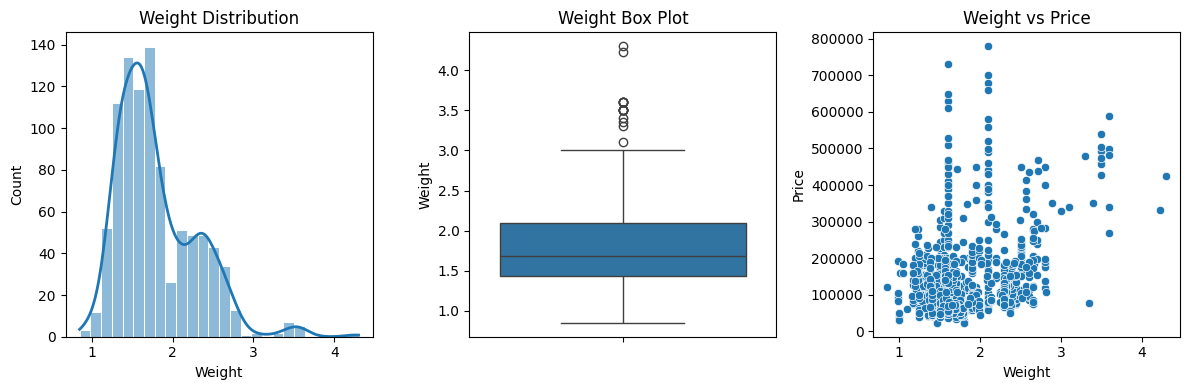

Skewness: 1.2028326845837953


In [26]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Weight'], kde=True, line_kws={'linewidth':2}, edgecolor='white', ax=ax[0])
ax[0].set_title('Weight Distribution')

sns.boxplot(data, y=data['Weight'], ax=ax[1])
ax[1].set_title('Weight Box Plot')

sns.scatterplot(data, x=data['Weight'], y=data['Price'], ax=ax[2])
ax[2].set_title('Weight vs Price')

plt.tight_layout()
plt.show()

print(f"Skewness: {data['Weight'].skew()}")

#### The Distribution is right skewed we can use Yeo-Johnson Transformation here and there are many outliers we can handle it by Robust Scaling.
#### The Weight vs Price Scatter Plot shows a non linear mixed sort of pattern, but this column might be useful for predicting laptop price as light weight and gaming laptops are expensive while budget laptops are mid-weight.

 ---

### Corelation Matrix:

In [27]:
numerical_cols_df = pd.DataFrame(data.drop(columns=['Brand', 'Laptop_Type', 'CPU_Brand', 'GPU_Type', 'Storage_Type', 'OS', 'CPU_Model', 'GPU_Model', 'GPU_VRAM', 'Resolution']))
numerical_cols_df.corr()

,Launch_Year,CPU_Cores,Screen_Size,Refresh_Rate,RAM,Storage,Weight,Price
Launch_Year,1.000000,0.217445,-0.021917,0.104244,0.381491,0.363787,-0.036224,0.425402
CPU_Cores,0.217445,1.000000,0.366719,0.565321,0.409958,0.399200,0.500872,0.619221
Screen_Size,-0.021917,0.366719,1.000000,0.486173,0.138833,0.112480,0.741811,0.280402
Refresh_Rate,0.104244,0.565321,0.486173,1.000000,0.225160,0.208492,0.726648,0.444755
RAM,0.381491,0.409958,0.138833,0.225160,1.000000,0.696395,0.174099,0.794228
Storage,0.363787,0.399200,0.112480,0.208492,0.696395,1.000000,0.169815,0.796571
Weight,-0.036224,0.500872,0.741811,0.726648,0.174099,0.169815,1.000000,0.362501
Price,0.425402,0.619221,0.280402,0.444755,0.794228,0.796571,0.362501,1.000000


#### RAM, Storage and CPU Cores had a high positive correlation with Price, so they are useful for predicting prize
#### Refresh Rate has not a strong but it has a good correlation with Price, so this column can't be droped yet.

 ---

## 3. High Cardinality Columns.

### a) CPU Model.

In [28]:
print(f"CPU Models: {data['CPU_Model'].nunique()}")

CPU Models: 138


In [29]:
print(f"Models: {data['CPU_Model'].sample(10, random_state=69).values}")

Models: ['Intel Core 7 150U' 'Intel Core i5 1334U' 'AMD Ryzen AI 9 365'
 'Intel Core Ultra 7 155H' 'Intel Core Ultra 7 155H' 'M5 Pro' 'M3 Max'
 'Intel Core Ultra 7 255HX' 'Intel Core i3 1315U' 'M5 Pro']


---

#### The CPU Model Column has a large number of distinct values, so we have to Feature Engineer this Column:
#### 1. Make 3 new Columns -> CPU_Series; CPU_Segemnet, CPU_Generation
#### 2. CPU_Series: [high, mid, low] -> Ordinal-Encoding 
1. Values -> **intel** (i3, i5, i7, i9, Core Ultra 5, Core Ultra 7, Core Ultra 9, Core 3, Core 5, Core 7, N); **AMD** (Ryzen 3, Ryzen 5, Ryzen 7, Ryzen 9, Ryzen 3 PRO,  Ryzen 5 PRO,  Ryzen 7 PRO, Ryzen AI 5, Ryzen AI 7, Ryzen AI 9, Ryzen AI 5 PRO, Ryzen AI MAX, Ryzen AI MAX+); **Apple** (M5, M5 Pro, M5 Max, M4, M4 Pro, M4 Max, M3, M3 Pro, M3 Max); **Qualcomm** (X Elite, X Plus, X).

2. Categorise these values into (high, mid, low) -> **high** (i7, i9, Core Ultra 7, Core Ultra 9, Ryzen 7, Ryzen 9, Ryzen 7 PRO, Ryzen AI 7, Ryzen AI 9,Ryzen AI MAX, Ryzen AI MAX+, M5 Pro, M5 Max, M4 Pro, M4 Max, M3 Pro, M3 Max, X Elite,); **mid** (i5, Core Ultra 5, Core 5, Core 7, Ryzen 5, Ryzen 5 PRO, Ryzen AI 5, Ryzen AI 5 PRO, M5, M4, M3, X Plus); **low** (i3, Core 3, Ryzen 3, Ryzen 3 PRO, X, Pentium, Celeron).

#### 3. CPU_Segement: [high, mid, low] -> Ordinal-Encoding
1. Extract suffix from columns (HX, H, HS, P, U, etc), then categorise them too -> **high** (H, HX, HS, Max, Pro, Elite); **mid** (P, Plus, M Base, X Base); **low** (U).

#### 4. CPU_Generation: [modern, latest] -> Ordinal-Encoding.
1. Intel_Gen ->  **latest** (Core Ultra Series 2); **Modern**(Core Ultra Sereis 1, 13, 14, Core Sereis)
2. AMD_Gen -> **latest** (contains AI); **modern** (5000, 7000, 8000, etc)
3. Apple_Gen -> **latest** (M5, M5 Pro, M5 MAX); **modern**(M4, M4 PRO, M4 Max, M3, M3 Pro, M3 Max)
4. Qualcomm_Gen -> **latest** (all)

---

### b) GPU Model

In [30]:
print(f"GPU Models: {data['GPU_Model'].nunique()}")

GPU Models: 52


In [31]:
print(f"Models: {data['GPU_Model'].sample(10, random_state=69).values}")

Models: ['Intel Iris Xe' 'Intel UHD' 'RTX 4050' 'Intel Arc' 'Intel Arc'
 'M5 Pro 20-Core GPU' 'M3 Max 30-Core GPU' 'RTX 5060' 'Intel UHD'
 'M5 Pro 20-Core GPU']


---

#### The GPU Model Column has many distinct values, we will feature engineer this column:
#### 1. Divide the column into 3 categories -> Low, Mid, High.
#### 2. High Tier -> RTX [5090, 5080, 5070 OR 5070Ti, 4090, 4080, 4070 or 4070Ti, etc] and [Apple GPU with more than 20 Cores].
#### 3. Mid Tier -> RTX [5060, 5050, 4060, 4050, 3050, 3060, 2050, etc] and [Apple GPU having 16-20 Cores].
#### 4. Low Tier -> Integrated GPU like [Intel Iris Xe, Intek Arc, AMD Radeon, Qualcomm Adreno, Apple, etc].
#### Then we can do "Ordinal-Encoding" on our GPU_Tier Column.

---

## 4) Columns Left For Analysis.

### a) Resolution.

In [32]:
print(f"dtype: {data['Resolution'].dtype}")
print(f"Values: {data['Resolution'].sample(6, random_state=69).values}")

dtype: object
Values: ['1920x1200' '1920x1080' '2880x1800' '2560x1600' '2880x1800' '3024x1964']


#### The Resolution column will be feature engineer with Screen Size Column to make a new Column PPI```(sqrt(ScreenW^2 + ScreenH^2)/Screen_Size)``` and then we will drop Resoltion and Screen Size Column.
#### We first the extraxt the value before 'x' into ScreenW Column and value after 'x' into ScreenH column from the Resolution Column.

---

#### b) GPU VRAM.

In [33]:
print(f"dtype: {data['GPU_VRAM'].dtype}")
print(f"Values: {data['GPU_VRAM'].sample(6, random_state=42).values}")

dtype: object
Values: ['8' 'Shared' '8' 'Shared' '6' '24']


#### Feature Engineer GPU VRAM Column, data['GPU_Vram'] == "Shared" will be converted to 0 and then convert its dtype to int.

 ---

# Feature Enginnering Columns:

### a) Brand.

In [34]:
data['Brand'] = data['Brand'].astype(object)

brand_counts = data['Brand'].value_counts()

data.loc[data['Brand'].map(brand_counts) <= 70, 'Brand'] = 'Others'

### b) Launch Year -> Laptop Age.

In [35]:
data['Laptop_Age'] = 2026 - data['Launch_Year']

data.drop(columns=['Launch_Year'], inplace=True)

### c) Screen Size, Resolution -> PPI.

In [36]:
data[['ScreenW', 'ScreenH']] = data['Resolution'].str.split('x', expand=True).astype(int)

data['Pixel_Per_Inch'] = np.sqrt(np.square(data['ScreenW']) + np.square(data['ScreenH'])) / data['Screen_Size']

data.drop(columns=['Screen_Size', 'Resolution', 'ScreenW', 'ScreenH'], inplace=True)

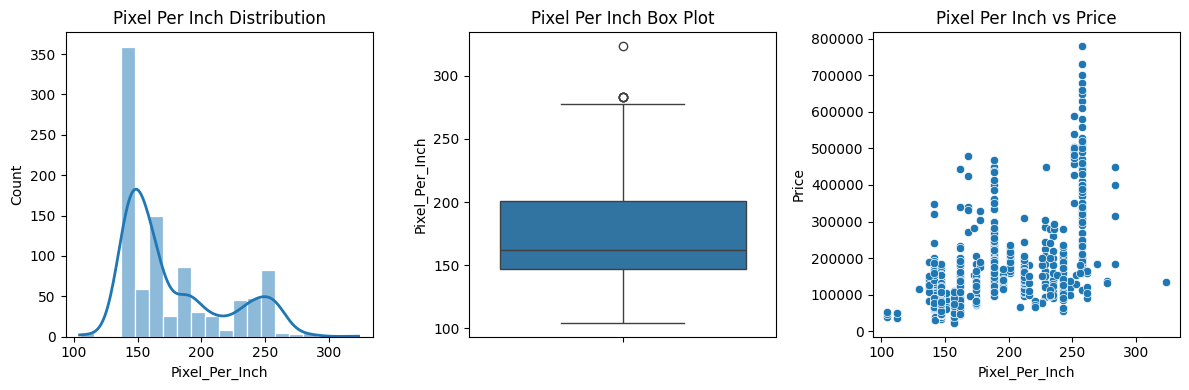

Skewness: 0.9531589665687787


In [37]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data, x=data['Pixel_Per_Inch'], kde=True, line_kws={'linewidth':2}, edgecolor='white', ax=ax[0])
ax[0].set_title('Pixel Per Inch Distribution')

sns.boxplot(data, y=data['Pixel_Per_Inch'], ax=ax[1])
ax[1].set_title('Pixel Per Inch Box Plot')

sns.scatterplot(data, x=data['Pixel_Per_Inch'], y=data['Price'], ax=ax[2])
ax[2].set_title('Pixel Per Inch vs Price')

plt.tight_layout()
plt.show()

print(f"Skewness: {data['Pixel_Per_Inch'].skew()}")

#### The Distribution is right skewed we can use Yeo-Johnson Transformation here and outliers can be handle by Robust Scaling.
#### There is a positive correlation with price, so this column is useful in predicting laptop prices.

### d) GPU VRAM.

In [38]:
data.loc[data['GPU_VRAM'] == 'Shared', 'GPU_VRAM'] = 0

data['GPU_VRAM'] = data['GPU_VRAM'].astype('int')

### e) GPU Model -> GPU_Tier.

In [39]:
data['GPU_Tier'] = 'low'

high_tier_GPU = 'RTX 4070|RTX 4070 Ti|RTX 4080|RTX 4090|RTX 5070|RTX 5070 Ti|RTX 5080|RTX 5090|M5 MAX|M4 MAX|M3 MAX|M5 Pro|M4 Pro|M3 Pro'
data.loc[data['GPU_Model'].str.contains(high_tier_GPU, case=False, na=False), 'GPU_Tier'] = 'high'

mid_tier_GPU = 'RTX 5060|RTX 5050|RTX 4060|RTX 4050|RTX 3060|RTX 3050|Intel Arc|660M|680M|760M|780M|840M|860M|880M|890M'
data.loc[data['GPU_Model'].str.contains(mid_tier_GPU, case=False, na=False), 'GPU_Tier'] = 'mid'

data.drop(columns=['GPU_Model'], inplace=True)

## f) CPU Model -> CPU_Series, CPU_Segment, CPU_Generation.

In [40]:
data['CPU_Series'] = 'low'

mid_series_CPU = 'i5|Ultra 5|Core 5| Core 7|Ryzen 5|Ryzen 5 PRO|Ryzen AI 5|Ryzen AI 5 PRO|M5|M4|M3|X Plus'
data.loc[data['CPU_Model'].str.contains(mid_series_CPU, case=False, na=False), 'CPU_Series'] = 'mid'

high_series_CPU = 'i7|i9|Ultra 7|Ultra 9|Ryzen 7| Ryzen 7 Pro|Ryzen 9|Ryzen AI 7|Ryzen AI 9|Ryzen AI MAX|Ryzen AI MAX+|M5 Pro|M5 MAX|M4 Pro|M4 MAX|M3 Pro|M3 MAX|X Elite'
data.loc[data['CPU_Model'].str.contains(high_series_CPU, case=False, na=False), 'CPU_Series'] = 'high'


data['CPU_Segment'] = 'mid'

high_segment_CPU = 'H|HX|HS|Max|Pro|Elite'
data.loc[data['CPU_Model'].str.contains(high_segment_CPU, case=False, na=False), 'CPU_Segment'] = 'high'

data.loc[data['CPU_Model'].str.endswith('U'), 'CPU_Segment'] = 'low'
data.loc[data['CPU_Model'].str.contains('Pentium|Celeron', case=False, na=False), 'CPU_Segment'] = 'low'


data['CPU_Generation'] = 'modern'

latest_gen_CPU = 'Snapdragon|M5|AI|Core Ultra'
data.loc[data['CPU_Model'].str.contains(latest_gen_CPU, case=False, na=False), 'CPU_Generation'] = 'latest'

data.drop(columns=['CPU_Model'], inplace=True)

---

## Correlation Heat-map.

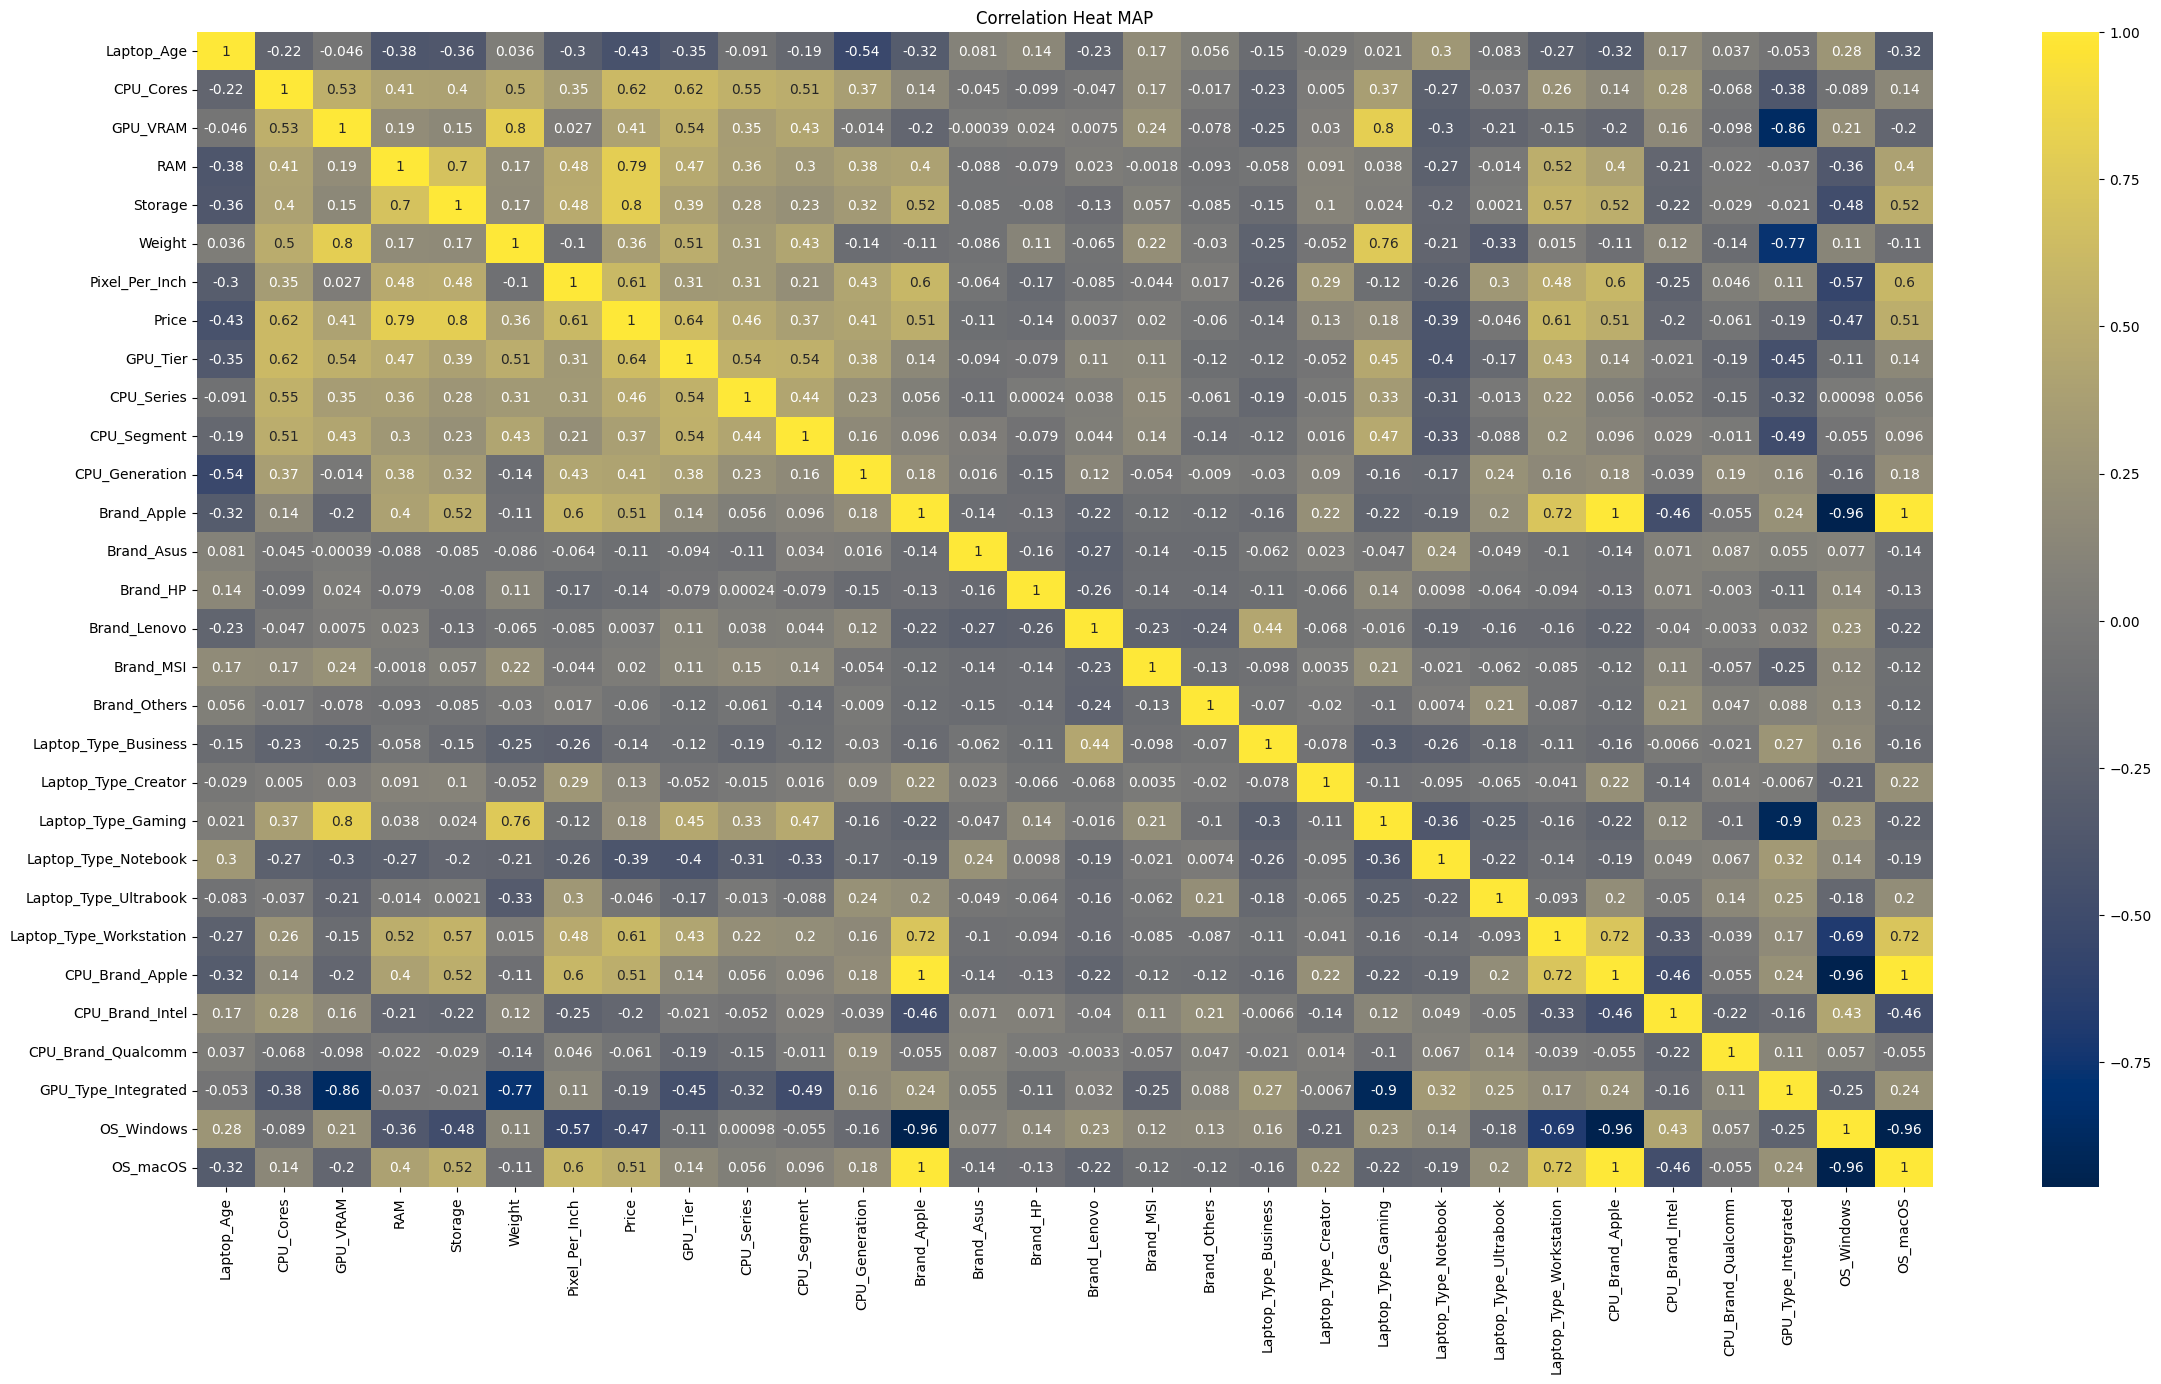

In [41]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

num_df = data[['Laptop_Age', 'CPU_Cores', 'GPU_VRAM', 'RAM', 'Storage', 'Weight', 'Pixel_Per_Inch', 'Price']]
oe_cols = data[['GPU_Tier', 'CPU_Series', 'CPU_Segment', 'CPU_Generation']]
ohe_cols = data[['Brand', 'Laptop_Type', 'CPU_Brand', 'GPU_Type', 'OS']]

oe = OrdinalEncoder(categories=[['low', 'mid', 'high'],['low', 'mid', 'high'],['low', 'mid', 'high'], ['modern', 'latest']])
oe_data = oe.fit_transform(oe_cols)

ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_data = ohe.fit_transform(ohe_cols)

oe_df = pd.DataFrame(oe_data, columns=oe_cols.columns)
ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out())

final_data = pd.concat([num_df, oe_df, ohe_df], axis=1)

corr = final_data.corr()

plt.figure(figsize=(28,15))
sns.heatmap(corr, annot=True, cmap='cividis')
plt.title('Correlation Heat MAP')

plt.show()

#### After Encoding there are some features that shows multicollinarity ['Brand_Apple -> OS_macOS & CPU_Brand_Apple'], we will drop 'Brand_Apple'. 

 ---

# Summary.

##### 1. Dataset has 2 duplicated values.
##### 2. Feature Engineering: ['Launch_Year' -> 'Laptop_Age', 'Screen_Size & Resolution' -> 'PPI', 'GPU_Model' -> 'GPU_Tier', 'CPU_Model' -> 'CPU_Series, CPU_Segement, CPU_Generation', 'GPU_VRAM', 'Brand'].
##### 3. One-Hot-Encoding: ['Brand', 'Laptop_Type', 'CPU_Brand', 'GPU_Type', 'OS'].
##### 4. Ordinal-Encoding: ['GPU_Tier', 'CPU_Series', 'CPU_Segment', 'CPU_Generation']
##### 5. Tansformation: ['Price, RAM, Storage' -> Log-Transformation, 'Weight, Pixel_Per_Inch' -> 'Yeo-Johnson']
##### 6. Robust-Scaling: ['Price', 'CPU_Cores', 'RAM', 'Storage', 'Pixel_Per_Inch']
##### 7. Drop: ['Storage_Type', 'Screen_Size', 'Resolution', 'CPU_Model', 'GPU_Model', 'Brand_Apple'].